# Experiment 5.5 — Non-SNN history-conditioned WHAT experts

This notebook is **analysis-only**. It reads finalized Exp5.5 CSV/JSON artifacts and never trains models, launches Slurm jobs, or regenerates missing runs.

Primary question: does history-conditioned mapping outperform shared WHAT, absolute elapsed time, and matched-capacity reset-GRU gating?

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'AGENTS.md').exists() and (candidate / 'scripts').is_dir():
            return candidate
    raise FileNotFoundError('repository root not found')

ROOT = find_repo_root() / 'notebooks' / 'artifacts' / 'experiment_5_5_non_snn_history_experts' / 'non_snn_history_experts_v1'
REQUIRED = [
    'references.csv', 'runs.csv', 'summary.csv', 'paired_deltas.csv',
    'state_diagnostics.csv', 'state_profiles.csv', 'q_only_probes.csv',
    'shuffled_q.csv', 'same_what_pairs.csv', 'manifest.json',
]
missing = [name for name in REQUIRED if not (ROOT / name).exists()]
if missing:
    raise FileNotFoundError(f'Exp5.5 is not finalized; missing artifacts: {missing}')
ROOT

PosixPath('/home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_5_5_non_snn_history_experts/non_snn_history_experts_v1')

## Locked protocol and aggregate metrics

In [2]:
manifest = json.loads((ROOT / 'manifest.json').read_text(encoding='utf-8'))
runs = pd.read_csv(ROOT / 'runs.csv')
summary = pd.read_csv(ROOT / 'summary.csv')
references = pd.read_csv(ROOT / 'references.csv')
paired = pd.read_csv(ROOT / 'paired_deltas.csv')
display(pd.DataFrame([manifest]))
display(summary.sort_values('mean_test_balanced_accuracy', ascending=False))
display(references)

,accumulator,clock_definition,conditions,experiment_id,expert_definition,gru_width,loss,multi_cpu_policy,n_states,notebook_policy,oracle_progress_definition,ordered_state_definition,protocol_version,reset_state_definition,seeds,selection_policy
0,valid-timestep evidence sum plus one final 12D...,8 smooth RBF probabilities over causal absolut...,"[shared, clock, oracle_progress, reset_gru, or...",experiment_5_5_non_snn_history_experts,K independent full 12x128 matrices with soft g...,64,whole-gesture cross entropy only,5 reference tasks -> 25 independent train/eval...,8,analysis-only; reads finalized CSV/JSON artifa...,8 smooth RBF probabilities over t/(T-1); diagn...,q_t = softmax(G h_{t-1}); h_{t-1} contains WHA...,non_snn_history_experts_v1,"q_t = softmax(G GRU(m_t, 0)); no cross-timeste...","[11, 23, 37, 53, 71]",all five conditions are predeclared; best epoc...


,condition,n_runs,trainable_parameter_count,mean_val_balanced_accuracy,sd_val_balanced_accuracy,mean_test_balanced_accuracy,sd_test_balanced_accuracy,sem_test_balanced_accuracy,mean_test_accuracy,mean_test_macro_f1
2,oracle_progress,5,12300,0.598077,0.012322,0.571931,0.036235,0.016205,0.582192,0.568902
1,clock,5,12300,0.575164,0.028262,0.550074,0.037300,0.016681,0.557534,0.538569
3,reset_gru,5,50068,0.550560,0.010404,0.503003,0.029939,0.013389,0.509589,0.495397
4,ordered_gru,5,50068,0.538443,0.014750,0.489864,0.035321,0.015796,0.494521,0.480491
0,shared,5,1548,0.466815,0.018736,0.444682,0.034719,0.015527,0.449315,0.441177


,seed,split_seed,fixed250_val_balanced_accuracy,fixed250_test_balanced_accuracy,fixed250_test_accuracy,fixed250_test_macro_f1,streaming_max_abs_delta
0,11,12345,0.525289,0.609449,0.623288,0.614180,1.421085e-14
1,23,12345,0.611562,0.593132,0.609589,0.591818,1.421085e-14
2,37,12345,0.545743,0.587313,0.595890,0.584473,1.598721e-14
3,53,12345,0.511165,0.585777,0.595890,0.583654,1.598721e-14
4,71,12345,0.542971,0.600482,0.616438,0.602123,1.065814e-14


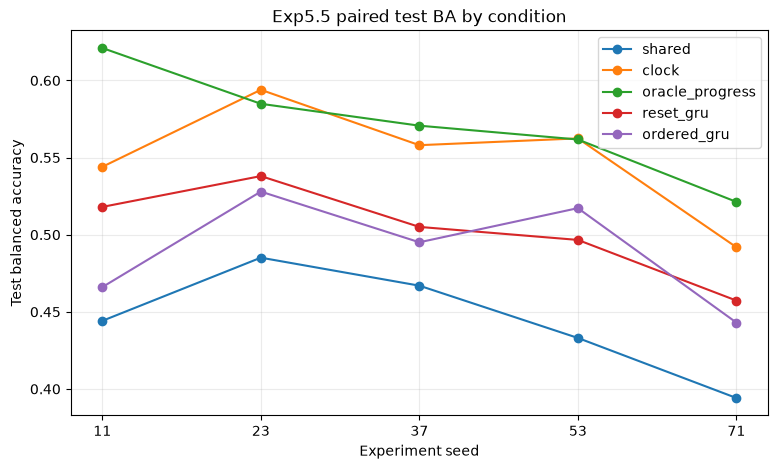

In [3]:
condition_order = ['shared', 'clock', 'oracle_progress', 'reset_gru', 'ordered_gru']
fig, ax = plt.subplots(figsize=(9, 5))
for condition in condition_order:
    group = runs[runs['condition'] == condition].sort_values('seed')
    ax.plot(group['seed'].astype(str), group['test_balanced_accuracy'], marker='o', label=condition)
ax.set_xlabel('Experiment seed')
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Exp5.5 paired test BA by condition')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## Paired mechanism contrasts

The most important contrast is `ordered_minus_reset`, which isolates recurrent history while holding GRU/state-head/expert capacity fixed.

,mean,std,min,max,count
comparison,,,,,
clock_minus_shared,0.105392,0.014845,0.091090,0.129397,5
reset_minus_shared,0.058321,0.013518,0.038102,0.073871,5
ordered_minus_shared,0.045182,0.024357,0.021877,0.084172,5
ordered_minus_shuffled_q,-0.013060,0.014602,-0.029204,0.010534,5
ordered_minus_reset,-0.013139,0.025833,-0.051993,0.020608,5
ordered_minus_clock,-0.060210,0.013323,-0.077985,-0.045225,5
ordered_minus_oracle_progress,-0.082067,0.043078,-0.155030,-0.044505,5


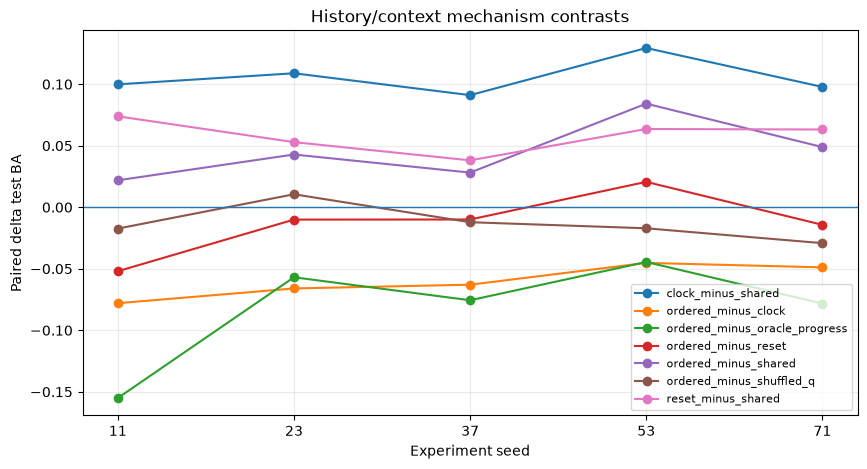

In [4]:
paired_summary = (paired.groupby('comparison')['delta_test_balanced_accuracy']
                  .agg(['mean', 'std', 'min', 'max', 'count'])
                  .sort_values('mean', ascending=False))
display(paired_summary)

fig, ax = plt.subplots(figsize=(10, 5))
for comparison, group in paired.groupby('comparison'):
    ax.plot(group['seed'].astype(str), group['delta_test_balanced_accuracy'], marker='o', label=comparison)
ax.axhline(0.0, linewidth=1)
ax.set_xlabel('Experiment seed')
ax.set_ylabel('Paired delta test BA')
ax.set_title('History/context mechanism contrasts')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.show()

## State occupancy, entropy, persistence, and clock/progress alignment

,condition,seed,metric,state,value
140,reset_gru,11,entropy_mean,NaN,1.957638
141,reset_gru,11,entropy_median,NaN,1.996300
142,reset_gru,11,total_variation_l1_mean,NaN,0.183221
143,reset_gru,11,argmax_transitions_per_second,NaN,21.841355
144,reset_gru,11,mean_dwell_seconds,NaN,0.044740
145,reset_gru,11,median_dwell_seconds,NaN,0.015625
146,reset_gru,11,occupancy,0.0,0.073840
147,reset_gru,11,occupancy,1.0,0.109906
148,reset_gru,11,occupancy,2.0,0.163943
149,reset_gru,11,occupancy,3.0,0.146845


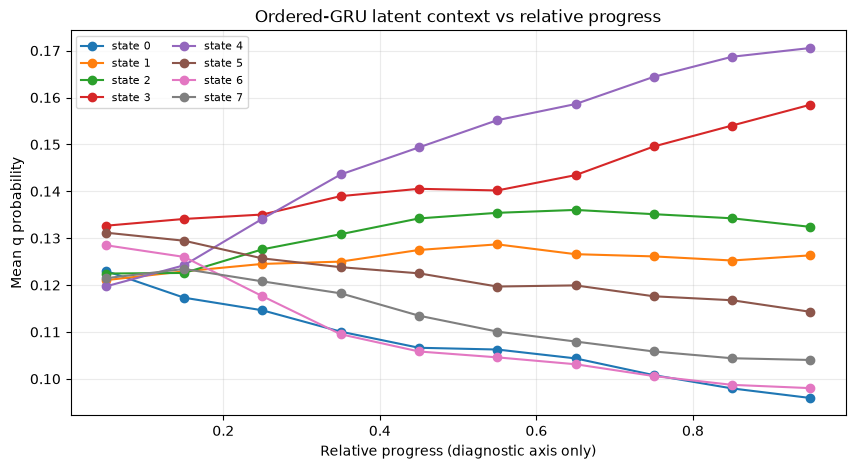

In [5]:
state_diag = pd.read_csv(ROOT / 'state_diagnostics.csv')
profiles = pd.read_csv(ROOT / 'state_profiles.csv')
display(state_diag[state_diag['condition'].isin(['reset_gru', 'ordered_gru'])].head(30))

ordered_profile = profiles[(profiles['condition'] == 'ordered_gru') & (profiles['axis'] == 'relative_progress')]
profile_mean = ordered_profile.groupby(['position', 'state'], as_index=False)['probability'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
for state, group in profile_mean.groupby('state'):
    ax.plot(group['position'], group['probability'], marker='o', label=f'state {int(state)}')
ax.set_xlabel('Relative progress (diagnostic axis only)')
ax.set_ylabel('Mean q probability')
ax.set_title('Ordered-GRU latent context vs relative progress')
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.25)
plt.show()

## q-only class information

High q-only BA near the full model would indicate that q may be collapsing toward a class code instead of serving mainly as context.

In [6]:
q_probe = pd.read_csv(ROOT / 'q_only_probes.csv')
q_test = q_probe[q_probe['split'] == 'test']
display(q_test.groupby(['condition', 'feature'])['balanced_accuracy'].agg(['mean', 'std', 'min', 'max']))

mean       std       min       max
condition   feature                                        
ordered_gru final_q  0.342695  0.041734  0.288018  0.392056
            mean_q   0.383864  0.046230  0.318603  0.427305
reset_gru   final_q  0.269905  0.035503  0.241614  0.325243
            mean_q   0.433200  0.044963  0.360044  0.471976

## Ordered-GRU temporal-alignment ablation

In [7]:
shuffled = pd.read_csv(ROOT / 'shuffled_q.csv')
display(shuffled.groupby('seed')['balanced_accuracy'].agg(['mean', 'std', 'min', 'max']))
display(paired[paired['comparison'] == 'ordered_minus_shuffled_q'])

,mean,std,min,max
seed,,,,
11,0.483373,0.006774,0.476446,0.489975
23,0.517421,0.008549,0.505859,0.525340
37,0.507273,0.006182,0.501045,0.513408
53,0.534339,0.005431,0.530584,0.542947
71,0.472216,0.010928,0.457990,0.488645


,seed,comparison,left_condition,right_condition,delta_test_balanced_accuracy
30,11,ordered_minus_shuffled_q,ordered_gru,ordered_gru_shuffled_q,-0.017343
31,23,ordered_minus_shuffled_q,ordered_gru,ordered_gru_shuffled_q,0.010534
32,37,ordered_minus_shuffled_q,ordered_gru,ordered_gru_shuffled_q,-0.012179
33,53,ordered_minus_shuffled_q,ordered_gru,ordered_gru_shuffled_q,-0.017109
34,71,ordered_minus_shuffled_q,ordered_gru,ordered_gru_shuffled_q,-0.029204


## Same-WHAT / different-history diagnostic

Rows compare highly similar nonzero frozen-WHAT vectors from different samples and classes, then report latent-context distance and local class-support changes.

In [8]:
same_what = pd.read_csv(ROOT / 'same_what_pairs.csv')
if same_what.empty:
    print('No same-WHAT diagnostic pairs were retained.')
else:
    display(same_what.sort_values(['high_similarity', 'what_cosine_similarity', 'q_l1_distance'], ascending=False).head(30))
    high = same_what[same_what['high_similarity'] == True]
    print('High-similarity pairs:', len(high))
    if len(high):
        print('Fraction with different top local support:', high['different_top_support'].mean())
        print('Mean q L1 distance:', high['q_l1_distance'].mean())
        print('Mean evidence L1 distance:', high['evidence_l1_distance'].mean())

,seed,sample_a,timestep_a,label_a,sample_b,timestep_b,label_b,what_cosine_similarity,q_l1_distance,evidence_l1_distance,top_support_a,top_support_b,different_top_support,high_similarity
0,11,76,28,1,130,64,7,1.0,0.094087,0.013095,8,8,False,True
1,11,124,33,8,76,28,1,1.0,0.084976,0.012364,8,8,False,True
2,11,80,37,2,76,28,1,1.0,0.081549,0.011264,8,8,False,True
3,11,80,43,2,76,28,1,1.0,0.081383,0.009850,8,8,False,True
400,71,46,62,3,63,16,10,1.0,0.072902,0.007700,8,8,False,True
300,53,3,22,4,56,5,3,1.0,0.062654,0.008773,6,6,False,True
200,37,132,13,6,101,12,1,1.0,0.056060,0.006700,8,8,False,True
201,37,122,8,2,115,12,4,1.0,0.055206,0.005523,3,3,False,True
401,71,30,23,7,76,13,1,1.0,0.053889,0.007305,1,8,True,True
202,37,103,7,5,25,16,2,1.0,0.046013,0.006019,8,8,False,True


High-similarity pairs: 79
Fraction with different top local support: 0.08860759493670886
Mean q L1 distance: 0.055183720173715
Mean evidence L1 distance: 0.1352148600809771


## Interpretation checklist

Strong support requires the evidence chain `ordered_gru > shared`, `ordered_gru > reset_gru`, `ordered_gru > clock`, and `ordered_gru > shuffled-q`, with q-only performance well below the full ordered model and same-WHAT pairs showing history-dependent q/evidence changes. `oracle_progress` is diagnostic: ordered beating it would support context beyond scalar progress; oracle beating ordered would indicate the expert mechanism works but history estimation remains limiting.